# 22. 미노출 생성기 탐지: Frozen MERT + 로지스틱 회귀

## 실험 질문

MusicGen 또는 Udio의 **FAKE 음악을 학습(Train)과 검증(Validation)에서 모두 제거**하면, 나머지 생성기로 학습한 탐지기가 해당 생성기의 Test 음악을 FAKE로 구분할 수 있을까?

## 실험 설계

- `segment_manifest_10s.csv`에 저장된 기존 Train·Validation·Test 분할을 그대로 사용한다. 같은 `original_audio`에서 나온 자료는 서로 다른 분할에 섞이지 않는다.
- **MusicGen 실험**과 **Udio 실험**을 독립적으로 진행한다. 각 실험의 Train·Validation에는 모든 REAL과 대상 생성기를 제외한 FAKE만 남긴다. Test에는 기존 Test REAL 전체와 대상 생성기의 Test FAKE만 넣는다.
- 10초 구간(segment)의 표현 벡터는 이미 추출된 **Frozen MERT 캐시**에서 읽는다. MERT 인코더를 다시 실행하거나 학습하지 않는다.
- 현재 binary 최적화 체크포인트 `checkpoints/optimized/mert_best.joblib`에서 선택된 MERT layer와 로지스틱 회귀 설정을 읽는다. 이전 17번 노트북은 오디오 패딩·풀링 방식이 달라 이 체크포인트와 혼용하지 않는다.
- 각 holdout에서 분류기와 `StandardScaler`를 새로 학습하되, scaler는 **Train에만 `fit`** 한다. 같은 곡(track)에 속한 segment의 FAKE 점수를 평균 내어 track 점수를 만든다.
- FAKE 점수가 높을수록 FAKE에 가깝다(`REAL=0`, `FAKE=1`). Track 판정 임계값은 **대상 생성기를 제외한 Validation**에서 `|FPR - FNR|`이 최소인 지점으로 정하고, Test에서는 고정한다. Test EER은 Test ROC에서 별도로 계산하는 지표이며, Test로 임계값을 다시 정하지 않는다.
- 기존 RBF-SVM·Log-Mel CNN 성능은 저장된 CSV에서 읽는다. 새 결과는 `results/mert_unseen_generator/`에만 저장한다. 재실행하면 이전 결과를 덮어쓰지 않고 `runs/`의 새 폴더에 저장한다.

**용어:** segment는 한 곡에서 잘라낸 10초 구간이고, track 점수는 그 곡에 속한 segment 점수들의 평균이다. 이 노트북의 표에서 AUC가 높을수록, EER·오탐률·미탐률은 낮을수록 좋다.

> 아래 셀별 숫자 요약은 **최초 저장된 실행 결과**를 설명한다. 나중에 다시 실행해 값이 달라지면 새 실행의 표와 결과 파일을 우선한다.

## 추가 분석: MP3 압축 강건성

7절에서는 **별도의 full-Test MP3 실험**을 수행한다. 기존 binary MERT 체크포인트의 학습된 scaler·LR·Validation 임계값을 모두 고정한 채, 같은 Test 곡의 원본 파일과 MP3 128/64 kbps 재인코딩본을 비교한다. 이 결과는 위 MusicGen/Udio holdout 분류기를 MP3로 평가한 것이 아니며, 두 실험의 Test 구성도 다르다. MP3 그림과 새 결과는 별도 `results/mert_mp3_robustness/`에 저장한다.

## 1. 입력 파일과 실험 설정 확인

이 셀들은 프로젝트 위치와 필요한 파일을 찾고, 저장된 binary MERT 체크포인트와 임베딩 캐시가 현재 데이터 목록과 일치하는지 검사한다. `assert`에서 멈추면 데이터가 누락되었거나 서로 다른 실험의 파일이 섞인 것이다.

In [13]:
# 파일 경로, 날짜, 표·수치 계산, 그림, 기존 체크포인트 로드에 필요한 라이브러리다.
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import (roc_curve, roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score, confusion_matrix)

# 현재 작업 폴더에서 시작해 상위 폴더 중 segment manifest가 있는 프로젝트 루트를 찾는다.
PROJECT_ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / "data/metadata/segment_manifest_10s.csv").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project directory or a child directory")
# 입력 경로는 모두 기존 산출물을 가리킨다. 이 셀에서는 입력 파일을 수정하지 않는다.
MANIFEST_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints/optimized/mert_best.joblib"
CACHE_DIR = PROJECT_ROOT / "data/processed/mert"
CACHE_STEM = "mert95m_binary_{}_validframe_12af15fef9d0"
SVM_METRICS_PATH = PROJECT_ROOT / "results/unseen_generator/unseen_generator_metrics_all.csv"
CNN_METRICS_PATH = PROJECT_ROOT / "results/cnn_unseen_generator/cnn_unseen_generator_metrics_all.csv"
# 결과 기본 폴더. 이미 결과가 있으면 아래에서 새 실행 폴더를 선택한다.
BASE_RESULT_DIR = PROJECT_ROOT / "results/mert_unseen_generator"
# 첫 실행은 기본 폴더를 쓰고, 재실행은 UTC 시각을 붙인 새 폴더를 사용한다.
RESULT_DIR = BASE_RESULT_DIR
# 기존 결과가 하나라도 있으면 덮어쓰지 않도록 runs/ 아래로 보낸다.
if BASE_RESULT_DIR.exists() and any(BASE_RESULT_DIR.iterdir()):
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    candidate = BASE_RESULT_DIR / "runs" / stamp
    suffix = 1
    while candidate.exists():
        candidate = BASE_RESULT_DIR / "runs" / f"{stamp}_{suffix}"
        suffix += 1
    RESULT_DIR = candidate
FIG_DIR = RESULT_DIR / "figures"
# 두 생성기는 서로 독립적인 holdout 실험이다.
HOLDOUTS = ("musicgen", "udio")

# 필요한 원본 파일과 Train·Validation/Test MERT 캐시 파일을 목록으로 만든다.
INPUTS = [MANIFEST_PATH, CHECKPOINT_PATH, SVM_METRICS_PATH, CNN_METRICS_PATH]
for split_name in ("train_val", "test"):
    stem = CACHE_STEM.format(split_name)
    INPUTS += [CACHE_DIR / f"{stem}.npy", CACHE_DIR / f"{stem}_index.csv",
               CACHE_DIR / f"{stem}_done.npy", CACHE_DIR / f"{stem}_meta.json"]
# 파일이 하나라도 없으면 학습 전에 중단한다.
missing = [str(p) for p in INPUTS if not p.is_file()]
if missing:
    raise FileNotFoundError("Missing required source artifact(s):\n" + "\n".join(missing))

# 이번 실행에서 만들 CSV·JSON·그림 이름을 미리 열거한다.
OUTPUTS = [RESULT_DIR / name for name in (
    "mert_unseen_metrics.csv", "mert_unseen_predictions_track.csv",
    "mert_unseen_predictions_segment.csv", "mert_unseen_dataset_counts.csv",
    "mert_unseen_comparison.csv", "mert_unseen_config.json")]
OUTPUTS += [FIG_DIR / name for name in (
    "unseen_generator_track_auc_mert_comparison.png",
    "unseen_generator_track_eer_mert_comparison.png",
    "unseen_generator_error_rates_mert_comparison.png",
    "mert_musicgen_unseen_confusion_matrix.png",
    "mert_udio_unseen_confusion_matrix.png")]
# 같은 경로의 파일이 이미 있으면 저장 전에 중단하여 덮어쓰기를 막는다.
assert not any(p.exists() for p in OUTPUTS), "Refusing to overwrite existing result output(s)"
print("Project root:", PROJECT_ROOT)
print("Existing source artifacts:", len(INPUTS))
print("Planned new outputs:", len(OUTPUTS))

Project root: <PROJECT_ROOT>
Existing source artifacts: 12
Planned new outputs: 11


**실행 결과 요약 — 경로 확인:** 필요한 입력 파일 12개가 확인됐다. 이미 첫 실험 결과가 있으므로 다시 실행하면 새 `runs/시간표기` 폴더를 사용한다. 여기서는 모델 학습이나 결과 저장이 일어나지 않는다.

In [14]:
# 10초 segment 목록을 불러온다. 각 행이 하나의 segment다.
segments = pd.read_csv(MANIFEST_PATH).reset_index(drop=True)
# 필요한 열과 고유 ID, REAL=0/FAKE=1, original_audio 그룹 분할을 검사한다.
required = {"segment_id", "track_sample_id", "original_audio", "label", "label_id",
            "genre", "generator", "split"}
assert required <= set(segments.columns)
assert segments["segment_id"].is_unique
assert segments.groupby("track_sample_id")[["label_id", "split", "original_audio"]].nunique().le(1).all().all()
assert set(segments["split"]) == {"train", "val", "test"}
assert set(zip(segments["label"], segments["label_id"])) == {("REAL", 0), ("FAKE", 1)}
assert segments.groupby("original_audio")["split"].nunique().eq(1).all()
assert segments.loc[segments["label_id"].eq(1), "generator"].notna().all()
# 파일 해시로 체크포인트·캐시가 같은 manifest에서 만들어졌는지 확인한다.
manifest_sha256 = hashlib.sha256(MANIFEST_PATH.read_bytes()).hexdigest()

# Validation으로 선택된 binary 모델의 설정을 읽는다. 이 학습된 분류기를 그대로 쓰지는 않는다.
binary = joblib.load(CHECKPOINT_PATH)
assert binary["kind"] == "best", "Expected validation-selected optimized binary checkpoint"
assert binary["model"] == "m-a-p/MERT-v1-95M"
assert binary["feature_dim"] == 768
# layer와 C를 숫자로 하드코딩하지 않고 체크포인트에서 가져온다.
selected_layer = int(binary["layer"])
LR_C = float(binary["C"])
# 뒤에서 clone()할 원본 scaler·분류기 객체다.
source_scaler = binary["scaler"]
source_clf = binary["classifier"]
assert source_clf.get_params()["C"] == LR_C
assert source_clf.classes_.tolist() == [0, 1]
assert source_scaler.n_features_in_ == binary["feature_dim"]
assert source_clf.n_features_in_ == binary["feature_dim"]
assert int(source_scaler.n_samples_seen_) == int(segments["split"].eq("train").sum())

# Train+Validation과 Test의 임베딩은 서로 다른 캐시 파일에 있다.
cache = {}
index = {}
meta = {}
for split_name, expected_splits in (("train_val", {"train", "val"}), ("test", {"test"})):
    stem = CACHE_STEM.format(split_name)
    # mmap_mode="r": 큰 캐시를 읽기 전용으로 열어 메모리 사용과 수정 위험을 줄인다.
    cache[split_name] = np.load(CACHE_DIR / f"{stem}.npy", mmap_mode="r")
    index[split_name] = pd.read_csv(CACHE_DIR / f"{stem}_index.csv")
    done = np.load(CACHE_DIR / f"{stem}_done.npy")
    meta[split_name] = json.loads((CACHE_DIR / f"{stem}_meta.json").read_text())
    # 캐시 index와 manifest의 segment 순서가 정확히 같은지 비교한다.
    expected = segments.loc[segments["split"].isin(expected_splits),
                            ["segment_id", "track_sample_id", "original_audio", "split"]].reset_index(drop=True)
    pd.testing.assert_frame_equal(index[split_name][expected.columns], expected, check_dtype=False)
    # [segment, 13개 표현 level, 768차원]인지, 추출 완료·유한값인지 검사한다.
    assert cache[split_name].shape == (len(expected), 13, 768)
    assert done.shape == (len(expected),) and bool(done.all())
    assert meta[split_name]["manifest_sha256"] == manifest_sha256
    assert meta[split_name]["model"] == binary["model"]
    assert meta[split_name]["revision"] == binary["revision"]
    assert meta[split_name]["pooling"] == binary["cache_meta"]["pooling"]
    assert meta[split_name]["input"] == binary["cache_meta"]["input"]
    assert set(meta[split_name]["splits"]) == expected_splits
    assert selected_layer in meta[split_name]["levels"]
    assert np.isfinite(cache[split_name][:, selected_layer, :]).all()
assert binary["manifest_sha256"] == manifest_sha256
assert len(segments) == sum(len(index[k]) for k in index)

# segment_id마다 어느 캐시의 몇 번째 행인지 찾는 표를 만든다.
lookup = {row.segment_id: (split_name, i)
          for split_name, df in index.items()
          for i, row in enumerate(df.itertuples(index=False))}
assert len(lookup) == len(segments)
print("Binary run:", binary["run_id"])
print("Frozen MERT:", binary["model"], binary["revision"])
print("Source checkpoint:", CHECKPOINT_PATH.relative_to(PROJECT_ROOT))
print("Selected level:", selected_layer, "/ 13; feature dimension:", binary["feature_dim"])
print("LR C:", LR_C, "solver:", source_clf.get_params()["solver"],
      "class_weight:", source_clf.get_params()["class_weight"])
print("Embedding cache:", {k: v.shape for k, v in cache.items()})
print("Input:", meta["train_val"]["input"])
print("Pooling:", meta["train_val"]["pooling"])
print("Original-audio groups by split:", segments.groupby("split")["original_audio"].nunique().to_dict())

Binary run: mert_binary_20260919T110741Z
Frozen MERT: m-a-p/MERT-v1-95M 12af15fef9d0ac838c3f475bfbbf26d2060dd4f5
Source checkpoint: checkpoints/optimized/mert_best.joblib
Selected level: 4 / 13; feature dimension: 768
LR C: 0.01 solver: lbfgs class_weight: balanced
Embedding cache: {'train_val': (8505, 13, 768), 'test': (1572, 13, 768)}
Input: 24kHz mono, original 10s boundary, no zero padding
Pooling: single-segment valid hidden frames mean
Original-audio groups by split: {'test': 45, 'train': 207, 'val': 44}


**실행 결과 요약 — MERT 설정:** 현재 최적화 binary 체크포인트는 **layer 4(0부터 시작하는 번호), LR `C=0.01`, `solver=lbfgs`, `class_weight=balanced`**를 선택했다. 캐시는 Train+Validation 8,505개, Test 1,572개 segment에 대해 각각 `[segment, 13, 768]` 모양이다. `original_audio` 그룹은 Train 207개·Validation 44개·Test 45개이며 분할 간 중복이 없다.

## 2. Holdout 데이터 만들기와 개수 확인

대상 생성기의 FAKE를 Train·Validation에서 제거한다. Test는 REAL 전체와 대상 생성기 FAKE만 남긴다. 제거 전후의 곡(track) 수와 10초 구간(segment) 수를 모두 확인한다.

In [15]:
# 기존 SVM/CNN unseen 실험과 같은 필터를 적용한다.
def build_holdout_data(df, holdout):
    # Train: REAL 전체 + 대상 생성기를 제외한 FAKE.
    train = df[(df["split"] == "train") &
               ((df["label_id"] == 0) | ((df["label_id"] == 1) & (df["generator"] != holdout)))].copy()
    # Validation도 같은 기준이다. 임계값 선택에 대상 생성기를 보여주지 않는다.
    val = df[(df["split"] == "val") &
             ((df["label_id"] == 0) | ((df["label_id"] == 1) & (df["generator"] != holdout)))].copy()
    # Test: 기존 Test REAL 전체 + 대상 생성기의 FAKE만 남긴다.
    test = df[(df["split"] == "test") &
              ((df["label_id"] == 0) | ((df["label_id"] == 1) & (df["generator"] == holdout)))].copy()
    return train, val, test

# track은 고유 track_sample_id 수, segment는 행 수로 센다.
def count_rows(df, holdout, split, stage):
    return {"holdout": holdout, "split": split, "stage": stage,
        "real_tracks": int(df.loc[df.label_id.eq(0), "track_sample_id"].nunique()),
        "fake_tracks": int(df.loc[df.label_id.eq(1), "track_sample_id"].nunique()),
        "real_segments": int(df.label_id.eq(0).sum()),
        "fake_segments": int(df.label_id.eq(1).sum()),
        "unique_original_audio": int(df.original_audio.nunique())}

# 생성기별 데이터와 제거 전·후 개수를 저장한다.
holdout_data = {}
count_records = []
for holdout in HOLDOUTS:
    train, val, test = build_holdout_data(segments, holdout)
    holdout_data[holdout] = (train, val, test)
    for split_name, filtered in (("train", train), ("val", val), ("test", test)):
        before = segments[segments.split.eq(split_name)]
        count_records.append(count_rows(before, holdout, split_name, "before"))
        count_records.append(count_rows(filtered, holdout, split_name, "after"))
    # 대상 생성기 FAKE가 Train·Validation에 남아 있으면 즉시 실패시킨다.
    assert not (train.generator.eq(holdout) & train.label_id.eq(1)).any()
    assert not (val.generator.eq(holdout) & val.label_id.eq(1)).any()
    assert test.loc[test.label_id.eq(1), "generator"].eq(holdout).all()
    assert set(test.loc[test.label_id.eq(0), "segment_id"]) == set(
        segments.loc[segments.split.eq("test") & segments.label_id.eq(0), "segment_id"])
    # 같은 original_audio가 서로 다른 split에 걸치지 않는지 다시 확인한다.
    assert set(train.original_audio).isdisjoint(val.original_audio)
    assert set(train.original_audio).isdisjoint(test.original_audio)
    assert set(val.original_audio).isdisjoint(test.original_audio)
    assert train.label_id.nunique() == val.label_id.nunique() == test.label_id.nunique() == 2
counts = pd.DataFrame(count_records)
display(counts)

,holdout,split,stage,real_tracks,fake_tracks,real_segments,fake_segments,unique_original_audio
0,musicgen,train,before,207,2185,621,6346,207
1,musicgen,train,after,207,1980,621,5731,207
2,musicgen,val,before,44,483,132,1406,44
3,musicgen,val,after,44,440,132,1277,44
4,musicgen,test,before,45,494,135,1437,45
5,musicgen,test,after,45,45,135,135,45
6,udio,train,before,207,2185,621,6346,207
7,udio,train,after,207,1981,621,5734,207
8,udio,val,before,44,483,132,1406,44
9,udio,val,after,44,435,132,1262,44


**실행 결과 요약 — 데이터 수:** MusicGen 제거 후 Train은 REAL/FAKE **207/1,980 track(621/5,731 segment)**, Validation은 **44/440 track(132/1,277 segment)**, Test는 **45/45 track(135/135 segment)**이다. Udio는 차례로 **207/1,981(621/5,734)**, **44/435(132/1,262)**, **45/48(135/144)**이다. 두 holdout 모두 대상 생성기 FAKE가 Train·Validation에 **0개**다. 전체 제거 전·후 수치는 위 표와 `mert_unseen_dataset_counts.csv`에 있다.

## 3. Holdout별 분류기 학습과 Validation 임계값 선택

저장된 binary 체크포인트에서 **설정만 복사**해 새로운 scaler·분류기를 만든다. Train으로 학습하고, 필터링된 Validation의 track 점수로 임계값을 정한 다음, 고정된 임계값으로 Test를 평가한다.

In [16]:
# segment_id를 캐시 행 번호로 바꿔 선택된 layer의 768차원 벡터를 읽는다.
def features_for(df):
    positions = [lookup[sid] for sid in df.segment_id]
    names = {name for name, _ in positions}
    assert names == ({"test"} if df.split.eq("test").all() else {"train_val"})
    # 모델 입력 행렬 X는 [segment 수, 768] 모양이다.
    X = np.empty((len(df), binary["feature_dim"]), dtype=np.float32)
    for name in names:
        target = [j for j, (source, _) in enumerate(positions) if source == name]
        rows = [positions[j][1] for j in target]
        X[target] = np.asarray(cache[name][rows, selected_layer, :], dtype=np.float32)
    assert np.isfinite(X).all()
    return X

# ROC의 FPR·TPR에서 FNR=1-TPR을 만들고, FPR과 FNR이 가장 가까운 지점을 고른다.
def find_eer_threshold(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1.0 - tpr
    # ROC가 돌려주는 무한대 임계값은 선택 후보에서 제외한다.
    finite = np.isfinite(thresholds)
    fpr, fnr, thresholds = fpr[finite], fnr[finite], thresholds[finite]
    choice = np.argmin(np.abs(fpr - fnr))
    return {"eer": float((fpr[choice] + fnr[choice]) / 2.0),
            "threshold": float(thresholds[choice])}

# 같은 track_sample_id의 segment FAKE 확률을 평균 내어 곡 점수를 만든다.
def make_track_scores(meta_df, scores):
    assert len(meta_df) == len(scores)
    temp = meta_df[["track_sample_id", "original_audio", "label", "label_id",
                    "genre", "generator", "split"]].copy()
    temp["score"] = scores
    assert temp.groupby("track_sample_id")[["label_id", "split", "original_audio"]].nunique().le(1).all().all()
    return temp.groupby("track_sample_id", as_index=False).agg(
        original_audio=("original_audio", "first"), label=("label", "first"),
        label_id=("label_id", "first"), genre=("genre", "first"),
        generator=("generator", "first"), split=("split", "first"),
        segment_count=("score", "size"), score=("score", "mean"))

# AUC/EER은 연속 점수로, 혼동행렬·F1 등은 고정 임계값의 0/1 판정으로 계산한다.
def evaluate_scores(y_true, scores, threshold):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    # 임계값 이상이면 FAKE(1), 미만이면 REAL(0)로 예측한다.
    pred = (scores >= threshold).astype(int)
    # 혼동행렬 순서: TN(REAL 정답), FP(REAL 오탐), FN(FAKE 미탐), TP(FAKE 정답).
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"n_total": int(len(y_true)), "n_real": int((y_true == 0).sum()),
        "n_fake": int((y_true == 1).sum()),
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
        "eer": find_eer_threshold(y_true, scores)["eer"],
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "macro_f1": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "real_fpr": float(fp / (tn + fp)), "fake_miss_rate": float(fn / (fn + tp)),
        "threshold_used": float(threshold),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

metric_rows, track_predictions, segment_predictions = [], [], []
thresholds, fitted_scaler_samples = {}, {}
# MusicGen과 Udio에서 scaler와 LR을 각각 새로 만든다.
for holdout in HOLDOUTS:
    train, val, test = holdout_data[holdout]
    print("\nHoldout:", holdout)
    # clone은 학습 가중치 없이 하이퍼파라미터만 복사한다.
    scaler = clone(source_scaler)
    clf = clone(source_clf)
    # 평균·표준편차 계산(fit)은 Train에만 수행한다.
    X_train = scaler.fit_transform(features_for(train))
    fitted_scaler_samples[holdout] = int(scaler.n_samples_seen_)
    assert fitted_scaler_samples[holdout] == len(train)
    # Train의 REAL(0)·FAKE(1)로 새 LR head를 학습한다. MERT 인코더는 학습하지 않는다.
    clf.fit(X_train, train.label_id.to_numpy(dtype=int))
    assert clf.classes_.tolist() == [0, 1]
    assert clf.get_params()["C"] == LR_C

    # Test를 읽기 전에 필터링된 Validation에서 점수와 임계값을 확정한다.
    # [:, 1]은 FAKE(클래스 1)의 예측 확률이다. Validation에는 transform만 적용한다.
    val_scores = clf.predict_proba(scaler.transform(features_for(val)))[:, 1]
    val_track = make_track_scores(val, val_scores)
    segment_val = find_eer_threshold(val.label_id, val_scores)
    # 주 결과에 사용할 track 임계값은 Validation track ROC에서만 정한다.
    track_val = find_eer_threshold(val_track.label_id, val_track.score)
    thresholds[holdout] = {"segment": segment_val["threshold"],
                           "track": track_val["threshold"],
                           "val_segment_eer": segment_val["eer"],
                           "val_track_eer": track_val["eer"]}
    print("Filtered Validation thresholds:", thresholds[holdout])

    # 확정된 모델·scaler로 Test를 예측한다. Test를 fit하거나 threshold 선택에 쓰지 않는다.
    test_scores = clf.predict_proba(scaler.transform(features_for(test)))[:, 1]
    test_track = make_track_scores(test, test_scores)
    # segment·track을 각각 평가하되 둘 다 해당 Validation 임계값을 사용한다.
    for level, y, scores, threshold, val_eer in (
        ("segment", test.label_id, test_scores, segment_val["threshold"], segment_val["eer"]),
        ("track", test_track.label_id, test_track.score, track_val["threshold"], track_val["eer"])):
        metric_rows.append({"holdout_generator": holdout, "model": "MERT+LR", "level": level,
            "test_type": "unseen_generator", "selected_mert_layer": selected_layer,
            "lr_C": LR_C, "val_eer": val_eer,
            **evaluate_scores(y, scores, threshold)})
    # 이후 오류 분석에 쓸 Test segment별 점수·임계값·예측을 저장한다.
    seg_pred = test[["segment_id", "track_sample_id", "original_audio", "label",
                     "label_id", "genre", "generator", "split"]].copy()
    seg_pred["holdout_generator"] = holdout
    seg_pred["score"] = test_scores
    seg_pred["threshold"] = segment_val["threshold"]
    seg_pred["pred"] = (test_scores >= segment_val["threshold"]).astype(int)
    segment_predictions.append(seg_pred)
    # track별 예측도 별도로 저장한다.
    track_pred = test_track.copy()
    track_pred["holdout_generator"] = holdout
    track_pred["threshold"] = track_val["threshold"]
    track_pred["pred"] = (track_pred.score >= track_val["threshold"]).astype(int)
    track_predictions.append(track_pred)
    print("Track Test:", metric_rows[-1])

# 두 holdout × 두 평가 단위 = 네 행의 MERT 결과 표다.
mert_metrics = pd.DataFrame(metric_rows)
segment_predictions = pd.concat(segment_predictions, ignore_index=True)
track_predictions = pd.concat(track_predictions, ignore_index=True)
display(mert_metrics.round(4))


Holdout: musicgen
Filtered Validation thresholds: {'segment': 0.5975149120025461, 'track': 0.5838492782058293, 'val_segment_eer': 0.09701063097695832, 'val_track_eer': 0.05000000000000001}
Track Test: {'holdout_generator': 'musicgen', 'model': 'MERT+LR', 'level': 'track', 'test_type': 'unseen_generator', 'selected_mert_layer': 4, 'lr_C': 0.01, 'val_eer': 0.05000000000000001, 'n_total': 90, 'n_real': 45, 'n_fake': 45, 'roc_auc': 0.9407407407407408, 'pr_auc': 0.9112948205913376, 'eer': 0.08888888888888888, 'balanced_accuracy': 0.8555555555555556, 'macro_f1': 0.855108359133127, 'real_fpr': 0.08888888888888889, 'fake_miss_rate': 0.2, 'threshold_used': 0.5838492782058293, 'tn': 41, 'fp': 4, 'fn': 9, 'tp': 36}

Holdout: udio
Filtered Validation thresholds: {'segment': 0.5778698346950816, 'track': 0.589972275429367, 'val_segment_eer': 0.08247490755414685, 'val_track_eer': 0.04686520376175548}
Track Test: {'holdout_generator': 'udio', 'model': 'MERT+LR', 'level': 'track', 'test_type': 'unseen

,holdout_generator,model,level,test_type,selected_mert_layer,lr_C,val_eer,n_total,n_real,n_fake,...,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,threshold_used,tn,fp,fn,tp
0,musicgen,MERT+LR,segment,unseen_generator,4,0.01,0.0970,270,135,135,...,0.1630,0.8111,0.8095,0.0963,0.2815,0.5975,122,13,38,97
1,musicgen,MERT+LR,track,unseen_generator,4,0.01,0.0500,90,45,45,...,0.0889,0.8556,0.8551,0.0889,0.2000,0.5838,41,4,9,36
2,udio,MERT+LR,segment,unseen_generator,4,0.01,0.0825,279,135,144,...,0.2007,0.7859,0.7784,0.0741,0.3542,0.5779,125,10,51,93
3,udio,MERT+LR,track,unseen_generator,4,0.01,0.0469,93,45,48,...,0.1292,0.8097,0.8053,0.0889,0.2917,0.5900,41,4,14,34


**실행 결과 요약 — MERT 성능:** Validation에서 선택한 **track 임계값**은 MusicGen **0.583849**, Udio **0.589972**다. 고정된 임계값으로 평가한 Test Track AUC/EER은 MusicGen **0.9407/0.0889**, Udio **0.9181/0.1292**다. MusicGen은 REAL 45곡 중 4곡을 FAKE로 오탐하고 FAKE 45곡 중 9곡을 놓쳤다. Udio는 REAL 45곡 중 4곡을 오탐하고 FAKE 48곡 중 14곡을 놓쳤다. EER은 Test ROC에서 별도로 계산했으며 임계값 선택에는 사용하지 않았다.

## 4. 기존 SVM·CNN 결과와 비교

기존 결과 CSV를 다시 계산하지 않고 읽는다. 세 모델이 같은 Test 곡을 평가했는지 곡 ID까지 확인한 후, MusicGen·Udio별 비교표를 만든다.

In [17]:
# 세 모델에서 공통으로 비교할 Track 지표를 정한다.
METRICS = ["roc_auc", "eer", "balanced_accuracy", "macro_f1", "real_fpr",
           "fake_miss_rate", "threshold_used", "tn", "fp", "fn", "tp"]
# SVM/CNN은 다시 학습하거나 예측하지 않고 기존 결과 CSV를 읽는다.
svm_all = pd.read_csv(SVM_METRICS_PATH)
cnn_all = pd.read_csv(CNN_METRICS_PATH)

# 기존 CSV에서 unseen-generator Test의 track 결과만 고른다.
def pick_existing(df, source_model, display_model):
    rows = df[(df.model == source_model) & (df.level == "track") &
              (df.test_type == "unseen_generator") & df.holdout_generator.isin(HOLDOUTS)].copy()
    assert len(rows) == len(HOLDOUTS) and rows.holdout_generator.is_unique
    assert set(METRICS + ["n_real", "n_fake"]) <= set(rows.columns)
    rows["model"] = display_model
    return rows

svm = pick_existing(svm_all, "RBF-SVM", "RBF-SVM")
cnn = pick_existing(cnn_all, "LogMelCNN", "Log-Mel CNN")
mert_track = mert_metrics[mert_metrics.level.eq("track")].copy()
# 모델마다 Test REAL·FAKE 개수가 MERT와 같은지 확인한다.
for source in (svm, cnn):
    for holdout in HOLDOUTS:
        old = source[source.holdout_generator.eq(holdout)].iloc[0]
        new = mert_track[mert_track.holdout_generator.eq(holdout)].iloc[0]
        assert (int(old.n_real), int(old.n_fake)) == (int(new.n_real), int(new.n_fake))
        assert (int(old.tn + old.fp), int(old.fn + old.tp)) == (int(new.n_real), int(new.n_fake))

# 단순한 개수 비교를 넘어 세 모델이 정확히 같은 Test 곡 ID를 평가했는지 확인한다.
for holdout in HOLDOUTS:
    expected_ids = set(track_predictions.loc[track_predictions.holdout_generator.eq(holdout), "track_sample_id"])
    svm_pred_path = PROJECT_ROOT / f"results/unseen_generator/{holdout}/rbf_svm_track_unseen_predictions.csv"
    cnn_pred_path = PROJECT_ROOT / f"results/cnn_unseen_generator/{holdout}/logmelcnn_track_unseen_predictions.csv"
    for p in (svm_pred_path, cnn_pred_path):
        assert p.is_file(), f"Missing cohort check artifact: {p}"
        old_pred = pd.read_csv(p)
        assert set(old_pred.track_sample_id) == expected_ids, f"Test track cohort differs: {p}"

# MusicGen·Udio 각각에서 SVM, CNN, MERT 순으로 여섯 행을 합친다.
comparison = pd.concat([svm, cnn, mert_track], ignore_index=True)
# 출력 순서를 MusicGen → Udio로 고정한다.
comparison["holdout_generator"] = pd.Categorical(comparison.holdout_generator,
    categories=HOLDOUTS, ordered=True)
# 출력 순서를 RBF-SVM → Log-Mel CNN → MERT+LR로 고정한다.
comparison["model"] = pd.Categorical(comparison.model,
    categories=["RBF-SVM", "Log-Mel CNN", "MERT+LR"], ordered=True)
comparison = comparison.sort_values(["holdout_generator", "model"]).reset_index(drop=True)
comparison = comparison[["holdout_generator", "model", "level", "test_type",
    "n_total", "n_real", "n_fake", "val_eer",
    "pr_auc", *METRICS]]
assert comparison.shape[0] == 6
assert np.isfinite(comparison[METRICS + ["n_total", "n_real", "n_fake"]].to_numpy(dtype=float)).all()
display(comparison.round(4))

,holdout_generator,model,level,test_type,n_total,n_real,n_fake,val_eer,pr_auc,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,threshold_used,tn,fp,fn,tp
0,musicgen,RBF-SVM,track,unseen_generator,90,45,45,0.0943,0.5886,0.6123,0.4000,0.5222,0.4669,0.1556,0.8000,0.8702,38,7,36,9
1,musicgen,Log-Mel CNN,track,unseen_generator,90,45,45,0.0636,0.8676,0.8681,0.2667,0.7333,0.7285,0.1333,0.4000,0.2817,39,6,18,27
2,musicgen,MERT+LR,track,unseen_generator,90,45,45,0.0500,0.9113,0.9407,0.0889,0.8556,0.8551,0.0889,0.2000,0.5838,41,4,9,36
3,udio,RBF-SVM,track,unseen_generator,93,45,48,0.1154,0.8804,0.8542,0.2368,0.7361,0.7266,0.1111,0.4167,0.8890,40,5,20,28
4,udio,Log-Mel CNN,track,unseen_generator,93,45,48,0.0833,0.8288,0.8227,0.2146,0.7653,0.7632,0.1778,0.2917,0.2331,37,8,14,34
5,udio,MERT+LR,track,unseen_generator,93,45,48,0.0469,0.9148,0.9181,0.1292,0.8097,0.8053,0.0889,0.2917,0.5900,41,4,14,34


**실행 결과 요약 — 세 모델 비교:** MusicGen Track AUC는 **SVM 0.6123, CNN 0.8681, MERT 0.9407**이다. Udio는 **SVM 0.8542, CNN 0.8227, MERT 0.9181**이다. 저장된 SVM/CNN Test 예측의 곡 ID가 MERT Test 곡 ID와 일치함을 확인했다. 여기서의 순위는 두 holdout 조건에 한정된다.

## 5. 결과 그림

Track AUC, Track EER, REAL 오탐률·FAKE 미탐률을 세 모델에 대해 비교한다. MERT의 혼동행렬에서는 **행이 실제값, 열이 예측값**이며 REAL(0)·FAKE(1) 순서다.

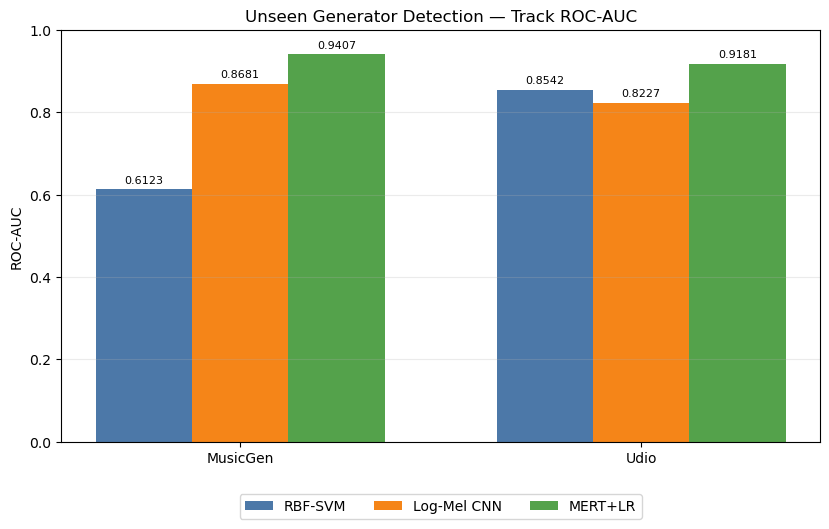

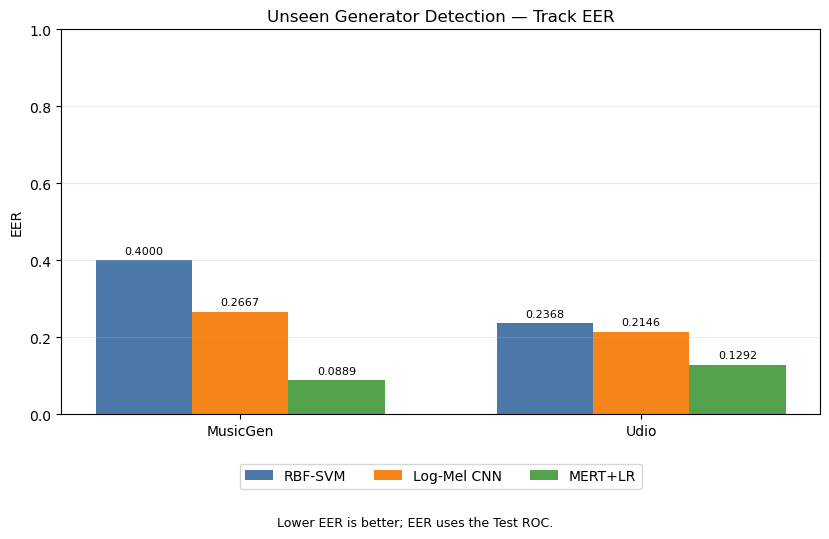

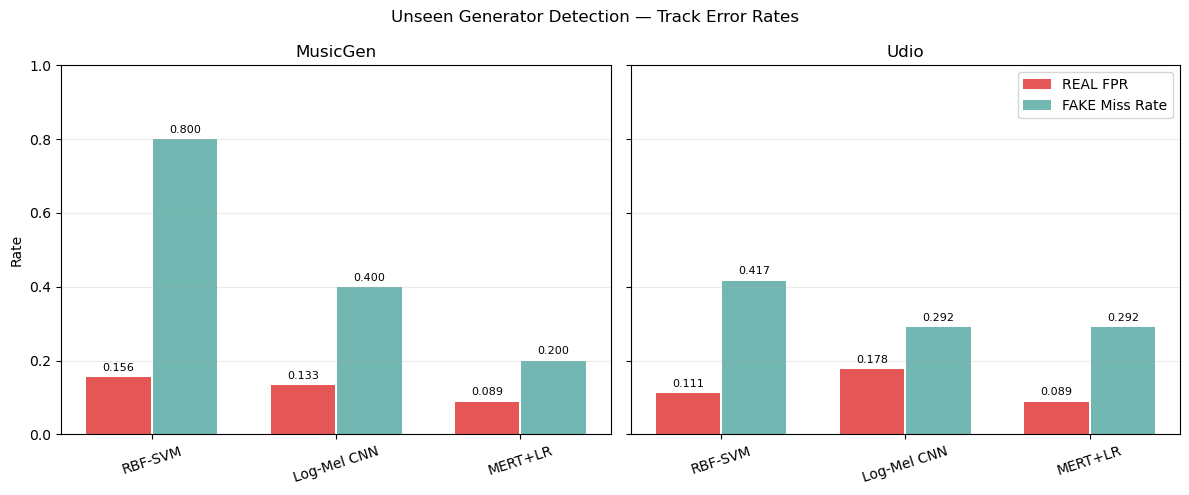

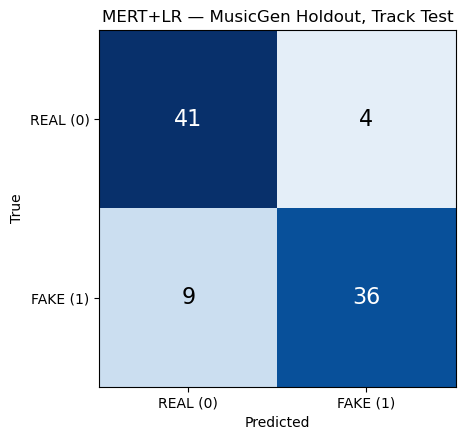

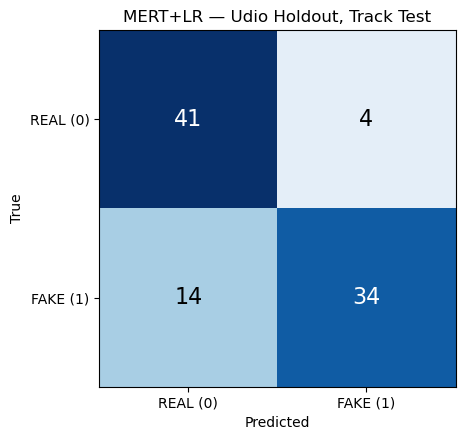

Optional Clean vs Unseen figure omitted: the saved MERT clean CSV is from the legacy layer-9/padded experiment. No saved clean layer-4/valid-frame per-generator AUC artifact exists for a three-model comparison.


In [18]:
# 이번 실행의 그림 폴더를 새로 만든다.
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ORDER = ["RBF-SVM", "Log-Mel CNN", "MERT+LR"]
HOLDOUT_LABELS = ["MusicGen", "Udio"]
COLORS = {"RBF-SVM": "#4C78A8", "Log-Mel CNN": "#F58518", "MERT+LR": "#54A24B"}

# 두 holdout마다 세 모델의 AUC 또는 EER을 나란히 그리는 공통 함수다.
def grouped_metric(metric, title, filename, caption=None):
    fig, ax = plt.subplots(figsize=(8.4, 5.4))
    x = np.arange(len(HOLDOUTS))
    width = 0.24
    for j, model in enumerate(MODEL_ORDER):
        # 저장된 비교표에서 해당 모델·holdout의 지표 한 값을 꺼낸다.
        vals = [float(comparison[(comparison.holdout_generator == h) &
                                 (comparison.model == model)][metric].iloc[0]) for h in HOLDOUTS]
        bars = ax.bar(x + (j - 1) * width, vals, width, label=model, color=COLORS[model])
        # 막대 위에 소수점 넷째 자리까지 수치를 쓴다.
        ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xticks(x, HOLDOUT_LABELS)
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric.upper() if metric == "eer" else "ROC-AUC")
    ax.set_title(title)
    if caption:
        fig.text(0.5, 0.015, caption, ha="center", fontsize=9)
    ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.11))
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout(rect=(0, 0.05 if caption else 0, 1, 1))
    path = FIG_DIR / filename
    # 같은 이름의 기존 그림을 덮어쓰지 않는다.
    assert not path.exists()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

grouped_metric("roc_auc", "Unseen Generator Detection — Track ROC-AUC",
    "unseen_generator_track_auc_mert_comparison.png")
grouped_metric("eer", "Unseen Generator Detection — Track EER",
    "unseen_generator_track_eer_mert_comparison.png", "Lower EER is better; EER uses the Test ROC.")

# 오류 방향: REAL FPR은 정상 음악 오탐, FAKE Miss Rate는 AI 음악 미탐이다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, holdout, label in zip(axes, HOLDOUTS, HOLDOUT_LABELS):
    subset = comparison[comparison.holdout_generator.eq(holdout)].set_index("model")
    xs = np.arange(len(MODEL_ORDER))
    for offset, field, name, color in ((-0.18, "real_fpr", "REAL FPR", "#E45756"),
                                      (0.18, "fake_miss_rate", "FAKE Miss Rate", "#72B7B2")):
        vals = subset.loc[MODEL_ORDER, field].astype(float).to_numpy()
        bars = ax.bar(xs + offset, vals, 0.35, label=name, color=color)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xticks(xs, MODEL_ORDER, rotation=18)
    ax.set_ylim(0, 1)
    ax.set_title(label)
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Rate")
axes[1].legend(loc="upper right")
fig.suptitle("Unseen Generator Detection — Track Error Rates")
fig.tight_layout()
path = FIG_DIR / "unseen_generator_error_rates_mert_comparison.png"
assert not path.exists()
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

# MERT만 MusicGen·Udio별 2×2 혼동행렬을 그린다.
for holdout in HOLDOUTS:
    row = mert_track[mert_track.holdout_generator.eq(holdout)].iloc[0]
    # 행=실제 REAL/FAKE, 열=예측 REAL/FAKE 순서다.
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]], dtype=int)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.imshow(cm, cmap="Blues", vmin=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], ["REAL (0)", "FAKE (1)"])
    ax.set_yticks([0, 1], ["REAL (0)", "FAKE (1)"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"MERT+LR — {dict(zip(HOLDOUTS, HOLDOUT_LABELS))[holdout]} Holdout, Track Test")
    fig.tight_layout()
    path = FIG_DIR / f"mert_{holdout}_unseen_confusion_matrix.png"
    assert not path.exists()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# 현재 설정과 일치하는 저장된 MERT clean generator별 결과가 없어 선택 그림은 건너뛴다.
print("Optional Clean vs Unseen figure omitted: the saved MERT clean CSV is from the legacy layer-9/padded experiment. No saved clean layer-4/valid-frame per-generator AUC artifact exists for a three-model comparison.")

**실행 결과 요약 — 그림 읽기:** AUC 그림에서는 높은 막대가, EER 그림에서는 낮은 막대가 좋다. 오류율 그림에서 REAL FPR은 정상 음악을 FAKE로 오탐한 비율, FAKE Miss Rate는 AI 음악을 REAL로 놓친 비율이다. MERT 혼동행렬의 MusicGen `TN/FP/FN/TP`는 **41/4/9/36**, Udio는 **41/4/14/34**다. 현재 layer 4 실험과 직접 비교할 저장된 MERT clean generator별 결과가 없어 선택 사항인 Clean vs Unseen 그림은 생성하지 않았다.

## 6. 품질 검사(QC)와 새 결과 저장

holdout 누출, 그룹 분할, scaler 학습 범위, 임계값 출처, 수치의 유한성 등을 검사한다. 모든 항목이 참일 때만 CSV·JSON을 새 파일로 저장한다.

In [19]:
# 결과에서 NaN·무한대를 검사할 수치 열을 정한다.
numeric_cols = ["n_total", "n_real", "n_fake", "roc_auc", "pr_auc", "eer",
    "balanced_accuracy", "macro_f1", "real_fpr", "fake_miss_rate", "threshold_used",
    "tn", "fp", "fn", "tp"]
# 각 조건을 True/False로 기록한다. 하나라도 False면 저장 전에 중단한다.
qc = {
    "frozen_MERT_cache_used": all(p.is_file() for p in INPUTS if "validframe" in str(p)),
    "MERT_encoder_not_fine_tuned": True,  # 이 노트북은 인코더를 만들지 않고 캐시만 읽는다.
    "selected_layer_matches_binary_checkpoint": all(mert_metrics.selected_mert_layer.eq(binary["layer"])),
    "C_matches_binary_checkpoint": all(mert_metrics.lr_C.eq(binary["C"])),
    "scaler_train_only_fit": all(fitted_scaler_samples[h] == len(holdout_data[h][0]) for h in HOLDOUTS),
    "musicgen_train_count_zero": not (holdout_data["musicgen"][0].generator.eq("musicgen") & holdout_data["musicgen"][0].label_id.eq(1)).any(),
    "musicgen_val_count_zero": not (holdout_data["musicgen"][1].generator.eq("musicgen") & holdout_data["musicgen"][1].label_id.eq(1)).any(),
    "udio_train_count_zero": not (holdout_data["udio"][0].generator.eq("udio") & holdout_data["udio"][0].label_id.eq(1)).any(),
    "udio_val_count_zero": not (holdout_data["udio"][1].generator.eq("udio") & holdout_data["udio"][1].label_id.eq(1)).any(),
    "original_audio_split_unchanged": segments.groupby("original_audio").split.nunique().eq(1).all(),
    # 저장된 track 점수가 segment 점수 평균과 실제로 같은지 재계산한다.
    "track_aggregation_is_segment_score_mean": all(
        np.allclose(track_predictions.loc[track_predictions.holdout_generator.eq(h)].sort_values("track_sample_id").score.to_numpy(),
            segment_predictions.loc[segment_predictions.holdout_generator.eq(h)].groupby("track_sample_id").score.mean().sort_index().to_numpy())
        for h in HOLDOUTS),
    "threshold_from_filtered_validation": all(
        np.isclose(mert_track.loc[mert_track.holdout_generator.eq(h), "threshold_used"].iloc[0], thresholds[h]["track"])
        for h in HOLDOUTS),
    "test_threshold_tuning_absent": True,  # 코드 순서상 Test 이전에 Validation 임계값을 확정한다.
    "test_REAL_0_FAKE_1": all(set(zip(d.label, d.label_id)) == {("REAL", 0), ("FAKE", 1)} for d in (holdout_data[h][2] for h in HOLDOUTS)),
    # 지표와 점수의 모든 수치값이 유한한지 검사한다.
    "results_no_NaN_Inf": np.isfinite(mert_metrics[numeric_cols + ["selected_mert_layer", "lr_C"]].to_numpy(dtype=float)).all()
        and np.isfinite(comparison[METRICS + ["n_total", "n_real", "n_fake"]].to_numpy(dtype=float)).all()
        and np.isfinite(track_predictions[["score", "threshold"]].to_numpy()).all()
        and np.isfinite(segment_predictions[["score", "threshold"]].to_numpy()).all(),
    "existing_artifact_not_overwritten": not any(p.exists() for p in OUTPUTS[:6]),
}
qc = {k: bool(v) for k, v in qc.items()}
display(pd.DataFrame([{"check": k, "pass": v} for k, v in qc.items()]))
# QC 실패 시 새 결과 파일을 저장하지 않는다.
assert all(qc.values()), "MERT UNSEEN GENERATOR QC FAIL"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
# open("x")는 파일이 이미 있으면 실패하므로 덮어쓰지 않는다.
def save_csv_exclusive(df, path):
    with path.open("x", encoding="utf-8-sig", newline="") as f:
        df.to_csv(f, index=False)
save_csv_exclusive(mert_metrics, RESULT_DIR / "mert_unseen_metrics.csv")
save_csv_exclusive(track_predictions, RESULT_DIR / "mert_unseen_predictions_track.csv")
save_csv_exclusive(segment_predictions, RESULT_DIR / "mert_unseen_predictions_segment.csv")
save_csv_exclusive(counts, RESULT_DIR / "mert_unseen_dataset_counts.csv")
save_csv_exclusive(comparison, RESULT_DIR / "mert_unseen_comparison.csv")
# 재현에 필요한 모델 설정·캐시·임계값·QC 결과를 JSON에 남긴다.
config = {
    "binary_run_id": binary["run_id"], "binary_checkpoint": str(CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
    "model": binary["model"], "revision": binary["revision"],
    "selected_mert_layer": selected_layer, "representation_levels": meta["train_val"]["levels"],
    "representation_dim": binary["feature_dim"], "sampling_rate": meta["train_val"]["processor_sampling_rate"],
    "segment_seconds": meta["train_val"]["segment_sec"],
    "cache_input": meta["train_val"]["input"], "cache_pooling": meta["train_val"]["pooling"],
    "cache_files": {name: str((CACHE_DIR / f"{CACHE_STEM.format(name)}.npy").relative_to(PROJECT_ROOT)) for name in cache},
    "manifest_sha256": manifest_sha256,
    "classifier_params": source_clf.get_params(), "scaler_params": source_scaler.get_params(),
    "fitted_train_samples": fitted_scaler_samples,
    "holdout_thresholds": thresholds,
    "test_protocol": "all original Test REAL plus Test FAKE from holdout generator",
    "threshold_rule": "filtered Validation track ROC: finite argmin(abs(FPR-(1-TPR)))",
    "track_score": "mean segment FAKE probability by track_sample_id",
    "existing_comparison_sources": [str(SVM_METRICS_PATH.relative_to(PROJECT_ROOT)),
                                    str(CNN_METRICS_PATH.relative_to(PROJECT_ROOT))],
    "optional_clean_comparison": "omitted: no saved optimized MERT clean per-generator AUC artifact",
    "qc": qc,
}
# JSON도 새 파일만 생성한다.
with (RESULT_DIR / "mert_unseen_config.json").open("x", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
assert all(p.exists() for p in OUTPUTS)
print("MERT UNSEEN GENERATOR QC PASS")
print("New outputs:")
for p in OUTPUTS:
    print(" -", p.relative_to(PROJECT_ROOT))

,check,pass
0,frozen_MERT_cache_used,True
1,MERT_encoder_not_fine_tuned,True
2,selected_layer_matches_binary_checkpoint,True
3,C_matches_binary_checkpoint,True
4,scaler_train_only_fit,True
5,musicgen_train_count_zero,True
6,musicgen_val_count_zero,True
7,udio_train_count_zero,True
8,udio_val_count_zero,True
9,original_audio_split_unchanged,True


MERT UNSEEN GENERATOR QC PASS
New outputs:
 - results/mert_unseen_generator/runs/20260921T033223Z/mert_unseen_metrics.csv
 - results/mert_unseen_generator/runs/20260921T033223Z/mert_unseen_predictions_track.csv
 - results/mert_unseen_generator/runs/20260921T033223Z/mert_unseen_predictions_segment.csv
 - results/mert_unseen_generator/runs/20260921T033223Z/mert_unseen_dataset_counts.csv
 - results/mert_unseen_generator/runs/20260921T033223Z/mert_unseen_comparison.csv
 - results/mert_unseen_generator/runs/20260921T033223Z/mert_unseen_config.json
 - results/mert_unseen_generator/runs/20260921T033223Z/figures/unseen_generator_track_auc_mert_comparison.png
 - results/mert_unseen_generator/runs/20260921T033223Z/figures/unseen_generator_track_eer_mert_comparison.png
 - results/mert_unseen_generator/runs/20260921T033223Z/figures/unseen_generator_error_rates_mert_comparison.png
 - results/mert_unseen_generator/runs/20260921T033223Z/figures/mert_musicgen_unseen_confusion_matrix.png
 - results/mer

**실행 결과 요약 — 저장과 QC:** 16개 QC 항목이 모두 참이라 **`MERT UNSEEN GENERATOR QC PASS`**가 출력된다. 새 CSV·JSON 6개와 그림 5개가 이번 실행 폴더에 저장된다. 원래의 SVM/CNN 결과 파일과 기존 MERT 체크포인트는 읽기만 한다.

## 7. MERT의 MP3 압축 강건성 — full Test

여기서는 **모든 생성기를 포함한 기존 Test**의 REAL 45곡과 FAKE 494곡을 사용한다. `original`은 원래 데이터 파일이며 반드시 무압축 오디오라는 뜻은 아니다. `mp3_128`과 `mp3_64`는 12번 실험에서 만든 동일한 곡의 MP3 재인코딩본이다. 세 조건의 MERT 임베딩은 곡 전체를 먼저 디코딩한 뒤 원래 10초 구간 위치로 잘라 저장한 캐시에서 읽는다. 이 방식은 이전 17번 노트북의 패딩 캐시와 다르다.

In [20]:
# 같은 Test segment를 세 조건에서 짝지어 평가할 수 있는지 먼저 확인한다.
MP3_CACHE_DIR = PROJECT_ROOT / "data/processed/model_robustness/mp3/mert"
MP3_TRANSCODE_REPORT = PROJECT_ROOT / "results/mp3_robustness/transcode_report.csv"
MP3_SVM_METRICS = PROJECT_ROOT / "results/mp3_robustness/mp3_robustness_metrics.csv"
MP3_CNN_METRICS = PROJECT_ROOT / "results/cnn_mp3_robustness/cnn_mp3_robustness_metrics.csv"
MP3_CONDITIONS = {"original": "clean", "mp3_128": "mp3_128", "mp3_64": "mp3_64"}
mp3_test = segments.loc[segments.split.eq("test")].reset_index(drop=True)
expected_index = mp3_test[["segment_id", "track_sample_id", "original_audio", "label_id"]]
assert mp3_test.segment_id.is_unique
assert mp3_test.groupby("original_audio").split.nunique().eq(1).all()

# 이미 저장된 결과가 있으면 새 실행 폴더를 골라 기존 CSV와 그림을 보호한다.
MP3_BASE_RESULT_DIR = PROJECT_ROOT / "results/mert_mp3_robustness"
MP3_RESULT_DIR = MP3_BASE_RESULT_DIR
if MP3_BASE_RESULT_DIR.exists() and any(MP3_BASE_RESULT_DIR.iterdir()):
    mp3_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    mp3_candidate = MP3_BASE_RESULT_DIR / "runs" / mp3_stamp
    mp3_suffix = 1
    while mp3_candidate.exists():
        mp3_candidate = MP3_BASE_RESULT_DIR / "runs" / f"{mp3_stamp}_{mp3_suffix}"
        mp3_suffix += 1
    MP3_RESULT_DIR = mp3_candidate
MP3_FIG_DIR = MP3_RESULT_DIR / "figures"
MP3_OUTPUTS = [MP3_RESULT_DIR / name for name in (
    "mert_mp3_metrics.csv", "mert_mp3_predictions_track.csv",
    "mert_mp3_predictions_segment.csv", "mert_mp3_track_comparison.csv",
    "mert_mp3_auc_change.csv", "mert_mp3_config.json")]
MP3_OUTPUTS += [MP3_FIG_DIR / name for name in (
    "mert_mp3_track_auc_comparison.png", "mert_mp3_track_eer_comparison.png",
    "mert_mp3_error_rates.png")]
assert not any(p.exists() for p in MP3_OUTPUTS)

# 전사 기록과 캐시 메타데이터의 해시를 대조해 같은 MP3 파일에서 추출됐는지 검사한다.
for path_in in (MP3_TRANSCODE_REPORT, MP3_SVM_METRICS, MP3_CNN_METRICS):
    assert path_in.is_file(), path_in
mp3_transcode_sha = hashlib.sha256(MP3_TRANSCODE_REPORT.read_bytes()).hexdigest()
mp3_transcode = pd.read_csv(MP3_TRANSCODE_REPORT)
expected_track_ids = set(mp3_test.track_sample_id)
for condition in ("mp3_128", "mp3_64"):
    part = mp3_transcode.loc[mp3_transcode.condition.eq(condition)]
    assert part.track_sample_id.is_unique and set(part.track_sample_id) == expected_track_ids
    assert part.ok.astype(str).str.lower().eq("true").all()
    assert all((PROJECT_ROOT / p).is_file() for p in part.compressed_path)

# mmap_mode="r"은 완성된 MERT 임베딩을 읽기 전용으로 연다.
mp3_cache, mp3_cache_meta = {}, {}
for condition, cache_condition in MP3_CONDITIONS.items():
    stem = f"mert95m_{cache_condition}_validframe_12af15fef9d0"
    cache_path = MP3_CACHE_DIR / f"{stem}.npy"
    index_path = MP3_CACHE_DIR / f"{stem}_index.csv"
    done_path = MP3_CACHE_DIR / f"{stem}_done.npy"
    meta_path = MP3_CACHE_DIR / f"{stem}_meta.json"
    assert all(p.is_file() for p in (cache_path, index_path, done_path, meta_path))
    mp3_cache[condition] = np.load(cache_path, mmap_mode="r")
    cached_index = pd.read_csv(index_path)
    done = np.load(done_path)
    mp3_cache_meta[condition] = json.loads(meta_path.read_text())
    meta = mp3_cache_meta[condition]
    pd.testing.assert_frame_equal(cached_index, expected_index, check_dtype=False)
    assert mp3_cache[condition].shape == (len(mp3_test), len(meta["levels"]), binary["feature_dim"])
    assert done.shape == (len(mp3_test),) and bool(done.all())
    assert np.isfinite(mp3_cache[condition][:, selected_layer, :]).all()
    assert meta["condition"] == cache_condition
    assert meta["model"] == binary["model"] and meta["revision"] == binary["revision"]
    assert meta["manifest_sha256"] == manifest_sha256
    assert meta["transcode_report_sha256"] == mp3_transcode_sha
    assert meta["pooling"] == binary["cache_meta"]["pooling"]
    assert meta["input"] == binary["cache_meta"]["input"]
    assert meta["processor_sampling_rate"] == binary["cache_meta"]["processor_sampling_rate"]
    assert meta["splits"] == ["test"] and selected_layer in meta["levels"]

assert binary["kind"] == "best" and binary["classifier"].classes_.tolist() == [0, 1]
assert set(mp3_test.label_id) == {0, 1}
print("MP3 Test:", mp3_test.track_sample_id.nunique(), "tracks /", len(mp3_test), "segments")
print("REAL / FAKE tracks:", mp3_test.loc[mp3_test.label_id.eq(0), "track_sample_id"].nunique(),
      "/", mp3_test.loc[mp3_test.label_id.eq(1), "track_sample_id"].nunique())
print("세 조건 캐시 완료:", {k: v.shape for k, v in mp3_cache.items()})
print("고정 설정: MERT layer", selected_layer, "/ LR C", binary["C"],
      "/ Track threshold", binary["thresholds"]["track"])
print("새 결과 위치:", MP3_RESULT_DIR.relative_to(PROJECT_ROOT))

MP3 Test: 539 tracks / 1572 segments
REAL / FAKE tracks: 45 / 494
세 조건 캐시 완료: {'original': (1572, 13, 768), 'mp3_128': (1572, 13, 768), 'mp3_64': (1572, 13, 768)}
고정 설정: MERT layer 4 / LR C 0.01 / Track threshold 0.5887511404871456
새 결과 위치: results/mert_mp3_robustness/runs/20260921T033224Z


**입력 QC 요약:** 세 조건 모두 동일한 Test 539곡(REAL 45, FAKE 494)·1,572개 구간(REAL 135, FAKE 1,437)의 임베딩을 사용한다. MERT 캐시의 index·완료 표시·모델 revision·manifest 및 MP3 전사 기록 해시를 대조한다. 분류기 설정과 Validation 임계값은 저장된 binary 체크포인트에서 읽는다.

### 7.1 고정된 MERT 분류기로 세 조건 평가

이 셀에서는 **새로 학습하지 않는다**. 기존 전체 생성기 binary 체크포인트의 scaler, LR, Segment/Track Validation 임계값을 그대로 적용한다. MP3 실험용 `clean` 캐시는 압축본과 같은 전체 곡 디코딩 절차로 만들었으므로 조건 간 변화량의 기준으로 사용한다. Test EER은 각 조건의 Test ROC에서 별도 계산한다.

In [21]:
mp3_metric_rows, mp3_segment_predictions, mp3_track_predictions = [], [], []
fixed_segment_threshold = float(binary["thresholds"]["segment"])
fixed_track_threshold = float(binary["thresholds"]["track"])

for condition in MP3_CONDITIONS:
    # 선택된 layer만 float32로 읽는다. scaler는 transform, LR은 predict_proba만 호출한다.
    X = np.asarray(mp3_cache[condition][:, selected_layer, :], dtype=np.float32)
    scores = binary["classifier"].predict_proba(binary["scaler"].transform(X))[:, 1]
    assert np.isfinite(scores).all()
    track_scores = make_track_scores(mp3_test, scores)  # 같은 곡의 segment 확률 평균
    assert set(track_scores.track_sample_id) == expected_track_ids

    # ROC-AUC/EER은 Test 점수로, 혼동행렬·F1은 고정 Validation 임계값으로 계산한다.
    for level, y, score_values, threshold in (
        ("segment", mp3_test.label_id, scores, fixed_segment_threshold),
        ("track", track_scores.label_id, track_scores.score, fixed_track_threshold)):
        mp3_metric_rows.append({"condition": condition, "model": "MERT+LR", "level": level,
            "selected_mert_layer": selected_layer, "lr_C": float(binary["C"]),
            **evaluate_scores(y, score_values, threshold)})

    segment_pred = mp3_test[["segment_id", "track_sample_id", "original_audio", "label",
                             "label_id", "genre", "generator", "split"]].copy()
    segment_pred["condition"] = condition
    segment_pred["score"] = scores
    segment_pred["threshold"] = fixed_segment_threshold
    segment_pred["pred"] = (scores >= fixed_segment_threshold).astype(int)
    mp3_segment_predictions.append(segment_pred)

    track_pred = track_scores.copy()
    track_pred["condition"] = condition
    track_pred["threshold"] = fixed_track_threshold
    track_pred["pred"] = (track_pred.score >= fixed_track_threshold).astype(int)
    mp3_track_predictions.append(track_pred)

mp3_metrics = pd.DataFrame(mp3_metric_rows)
mp3_segment_predictions = pd.concat(mp3_segment_predictions, ignore_index=True)
mp3_track_predictions = pd.concat(mp3_track_predictions, ignore_index=True)
mp3_mert_track = mp3_metrics.loc[mp3_metrics.level.eq("track")].copy()
clean_track_auc = float(mp3_mert_track.loc[mp3_mert_track.condition.eq("original"), "roc_auc"].iloc[0])
mp3_auc_change = mp3_mert_track[["condition", "roc_auc", "eer", "balanced_accuracy",
                                  "real_fpr", "fake_miss_rate"]].copy()
mp3_auc_change["auc_drop_from_original"] = clean_track_auc - mp3_auc_change.roc_auc
print("MERT MP3 Track 결과 (임계값은 모든 조건에서 고정):")
display(mp3_mert_track[["condition", "roc_auc", "eer", "balanced_accuracy", "macro_f1",
                        "real_fpr", "fake_miss_rate", "threshold_used", "tn", "fp", "fn", "tp"]].round(4))
display(mp3_auc_change.round(4))

MERT MP3 Track 결과 (임계값은 모든 조건에서 고정):


,condition,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,threshold_used,tn,fp,fn,tp
1,original,0.9845,0.0738,0.9363,0.8787,0.0889,0.0385,0.5888,41,4,19,475
3,mp3_128,0.9851,0.0708,0.9444,0.9150,0.0889,0.0223,0.5888,41,4,11,483
5,mp3_64,0.9605,0.1102,0.8485,0.8709,0.2889,0.0142,0.5888,32,13,7,487


,condition,roc_auc,eer,balanced_accuracy,real_fpr,fake_miss_rate,auc_drop_from_original
1,original,0.9845,0.0738,0.9363,0.0889,0.0385,0.0000
3,mp3_128,0.9851,0.0708,0.9444,0.0889,0.0223,-0.0006
5,mp3_64,0.9605,0.1102,0.8485,0.2889,0.0142,0.0240


**MERT 결과 요약:** Track AUC는 `original` **0.9845**, `mp3_128` **0.9851**, `mp3_64` **0.9605**다. 짝지어진 original 대비 AUC 차이는 128 kbps **−0.0006**(미세한 상승), 64 kbps **+0.0240**(하락)이다. 64 kbps에서 REAL 오탐은 **4/45 → 13/45**로 늘었고, FAKE 미탐은 **19/494 → 7/494**로 줄었다. 이는 고정 임계값 아래 오류 방향이 변한 결과이며, 128 kbps의 작은 AUC 상승을 압축의 일반적 개선 효과로 해석하지 않는다.

### 7.2 저장된 SVM·CNN MP3 결과와 비교

12번 SVM·15번 CNN의 **같은 전체 Test cohort** 결과 CSV를 읽고 세 모델의 Track 지표를 정리한다. SVM·CNN과 MERT는 입력 표현과 학습 체크포인트가 다르므로, 여기서는 각 모델이 압축 조건에서 보인 변화 방향을 함께 살펴본다.

In [22]:
svm_mp3_all = pd.read_csv(MP3_SVM_METRICS)
cnn_mp3_all = pd.read_csv(MP3_CNN_METRICS)
svm_mp3 = svm_mp3_all.loc[(svm_mp3_all.model.eq("RBF-SVM")) &
                          (svm_mp3_all.level.eq("track"))].copy()
cnn_mp3 = cnn_mp3_all.loc[cnn_mp3_all.level.eq("track")].copy()
cnn_mp3["model"] = "Log-Mel CNN"
assert set(svm_mp3.condition) == set(cnn_mp3.condition) == set(MP3_CONDITIONS)

mp3_common_cols = ["condition", "model", "level", "roc_auc", "pr_auc", "eer",
    "balanced_accuracy", "macro_f1", "real_fpr", "fake_miss_rate", "threshold_used",
    "tn", "fp", "fn", "tp"]
mp3_comparison = pd.concat([svm_mp3[mp3_common_cols], cnn_mp3[mp3_common_cols],
                            mp3_mert_track[mp3_common_cols]], ignore_index=True)
mp3_comparison["condition"] = pd.Categorical(mp3_comparison.condition,
    categories=list(MP3_CONDITIONS), ordered=True)
mp3_comparison["model"] = pd.Categorical(mp3_comparison.model,
    categories=["RBF-SVM", "Log-Mel CNN", "MERT+LR"], ordered=True)
mp3_comparison = mp3_comparison.sort_values(["condition", "model"]).reset_index(drop=True)
assert len(mp3_comparison) == 9
for row in mp3_comparison.itertuples():
    assert (row.tn + row.fp, row.fn + row.tp) == (
        int(mp3_test.loc[mp3_test.label_id.eq(0), "track_sample_id"].nunique()),
        int(mp3_test.loc[mp3_test.label_id.eq(1), "track_sample_id"].nunique()))
print("동일 Test 539곡 기준 세 모델 MP3 Track 비교:")
display(mp3_comparison[["condition", "model", "roc_auc", "eer", "balanced_accuracy",
                        "macro_f1", "real_fpr", "fake_miss_rate"]].round(4))

동일 Test 539곡 기준 세 모델 MP3 Track 비교:


,condition,model,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate
0,original,RBF-SVM,0.9644,0.1395,0.8696,0.7502,0.1556,0.1053
1,original,Log-Mel CNN,0.9772,0.1042,0.9111,0.8535,0.1333,0.0445
2,original,MERT+LR,0.9845,0.0738,0.9363,0.8787,0.0889,0.0385
3,mp3_128,RBF-SVM,0.9536,0.1325,0.8676,0.7692,0.1778,0.0870
4,mp3_128,Log-Mel CNN,0.8954,0.1830,0.7626,0.7765,0.4444,0.0304
5,mp3_128,MERT+LR,0.9851,0.0708,0.9444,0.9150,0.0889,0.0223
6,mp3_64,RBF-SVM,0.9062,0.1688,0.8494,0.7437,0.2000,0.1012
7,mp3_64,Log-Mel CNN,0.8256,0.2892,0.7179,0.5430,0.2444,0.3198
8,mp3_64,MERT+LR,0.9605,0.1102,0.8485,0.8709,0.2889,0.0142


**세 모델 비교 요약:** 64 kbps에서 original 대비 Track AUC 하락은 RBF-SVM **0.0583**, Log-Mel CNN **0.1516**, MERT+LR **0.0240**이었다. 이 수치는 동일한 539개 Test 곡에서 관찰한 **각 모델 내부의 변화량**이다. 다른 생성기·압축 방식에서도 같은 순위가 유지된다는 뜻은 아니다.

### 7.3 MP3 QC, 결과 저장 및 그림

세 조건의 Test ID·캐시·임계값과 모든 수치가 유효한지 확인한 후 새 결과 폴더에만 저장한다. 그림은 AUC, EER, MERT의 REAL 오탐률·FAKE 미탐률을 보여준다.

,검사,통과
0,three_completed_frozen_MERT_caches,True
1,same_Test_segment_and_track_ids,True
2,same_manifest_revision_and_pooling,True
3,no_MERT_fine_tuning_or_new_LR_fit,True
4,fixed_segment_Validation_threshold,True
5,fixed_track_Validation_threshold,True
6,same_track_score_mean,True
7,REAL_0_FAKE_1,True
8,all_metrics_finite,True
9,no_existing_result_overwrite,True


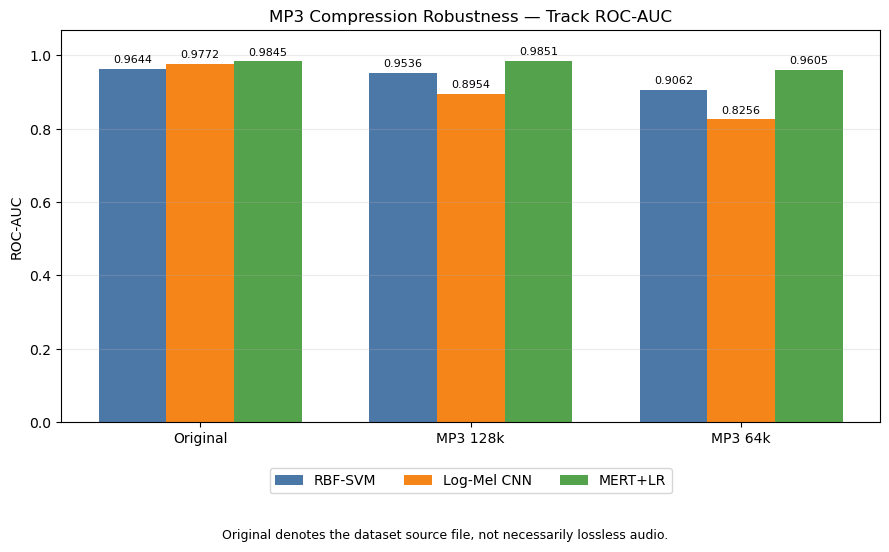

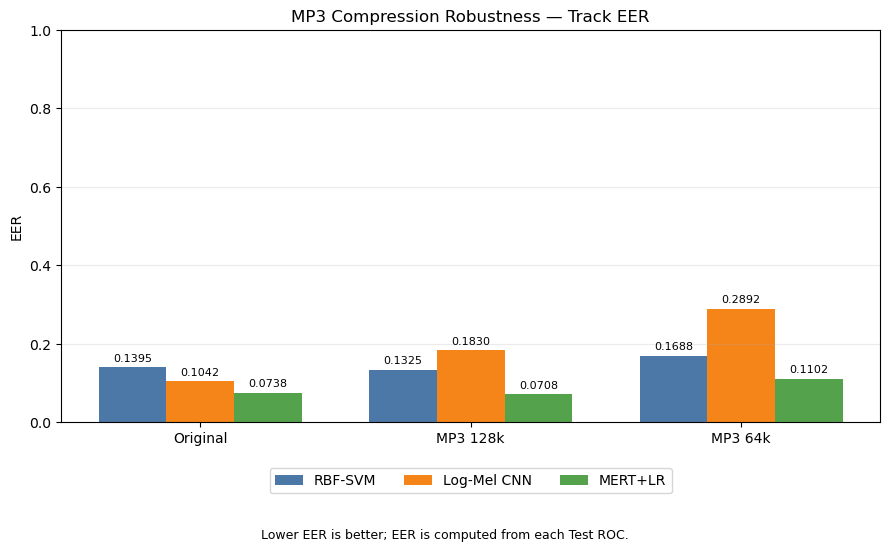

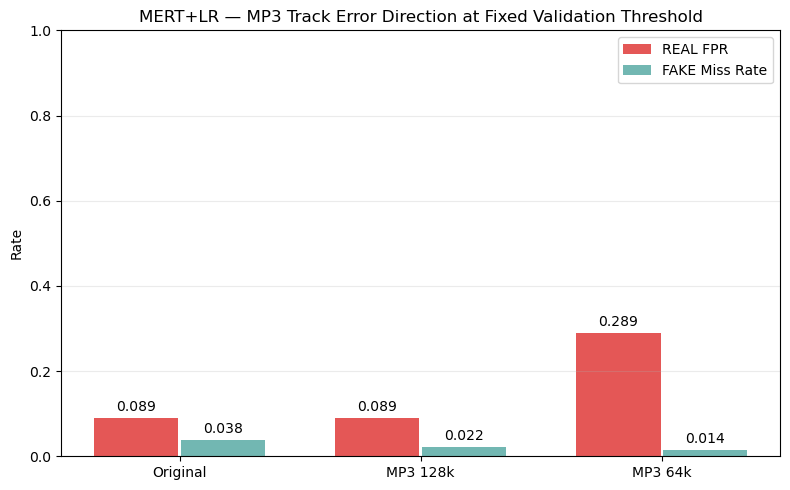

MERT MP3 QC PASS
새 결과 파일:
 - results/mert_mp3_robustness/runs/20260921T033224Z/mert_mp3_metrics.csv
 - results/mert_mp3_robustness/runs/20260921T033224Z/mert_mp3_predictions_track.csv
 - results/mert_mp3_robustness/runs/20260921T033224Z/mert_mp3_predictions_segment.csv
 - results/mert_mp3_robustness/runs/20260921T033224Z/mert_mp3_track_comparison.csv
 - results/mert_mp3_robustness/runs/20260921T033224Z/mert_mp3_auc_change.csv
 - results/mert_mp3_robustness/runs/20260921T033224Z/mert_mp3_config.json
 - results/mert_mp3_robustness/runs/20260921T033224Z/figures/mert_mp3_track_auc_comparison.png
 - results/mert_mp3_robustness/runs/20260921T033224Z/figures/mert_mp3_track_eer_comparison.png
 - results/mert_mp3_robustness/runs/20260921T033224Z/figures/mert_mp3_error_rates.png


In [23]:
mp3_numeric = ["roc_auc", "pr_auc", "eer", "balanced_accuracy", "macro_f1",
               "real_fpr", "fake_miss_rate", "threshold_used", "tn", "fp", "fn", "tp"]
mp3_qc = {
    "three_completed_frozen_MERT_caches": len(mp3_cache) == 3 and all(
        np.isfinite(v[:, selected_layer, :]).all() for v in mp3_cache.values()),
    "same_Test_segment_and_track_ids": all(
        set(mp3_segment_predictions.loc[mp3_segment_predictions.condition.eq(c), "segment_id"]) == set(mp3_test.segment_id)
        and set(mp3_track_predictions.loc[mp3_track_predictions.condition.eq(c), "track_sample_id"]) == expected_track_ids
        for c in MP3_CONDITIONS),
    "same_manifest_revision_and_pooling": all(
        m["manifest_sha256"] == manifest_sha256 and m["revision"] == binary["revision"]
        and m["pooling"] == binary["cache_meta"]["pooling"] for m in mp3_cache_meta.values()),
    "no_MERT_fine_tuning_or_new_LR_fit": True,  # 이 절은 저장된 캐시·scaler·LR만 사용한다.
    "fixed_segment_Validation_threshold": mp3_metrics.loc[mp3_metrics.level.eq("segment"), "threshold_used"].eq(fixed_segment_threshold).all(),
    "fixed_track_Validation_threshold": mp3_mert_track.threshold_used.eq(fixed_track_threshold).all(),
    "same_track_score_mean": all(np.allclose(
        mp3_track_predictions.loc[mp3_track_predictions.condition.eq(c)].sort_values("track_sample_id").score,
        mp3_segment_predictions.loc[mp3_segment_predictions.condition.eq(c)].groupby("track_sample_id").score.mean().sort_index())
        for c in MP3_CONDITIONS),
    "REAL_0_FAKE_1": set(zip(mp3_test.label, mp3_test.label_id)) == {("REAL", 0), ("FAKE", 1)},
    "all_metrics_finite": np.isfinite(mp3_metrics[mp3_numeric].to_numpy(dtype=float)).all()
        and np.isfinite(mp3_comparison[mp3_numeric].to_numpy(dtype=float)).all(),
    "no_existing_result_overwrite": not any(p.exists() for p in MP3_OUTPUTS),
}
mp3_qc = {k: bool(v) for k, v in mp3_qc.items()}
display(pd.DataFrame([{"검사": k, "통과": v} for k, v in mp3_qc.items()]))
assert all(mp3_qc.values()), "MERT MP3 QC FAIL"

# x 모드는 기존 파일을 덮어쓰지 않는다. 이 함수는 MP3 절만 다시 실행할 때도 독립적으로 동작한다.
MP3_RESULT_DIR.mkdir(parents=True, exist_ok=True)
def save_mp3_csv_exclusive(df, path):
    with path.open("x", encoding="utf-8-sig", newline="") as f:
        df.to_csv(f, index=False)
save_mp3_csv_exclusive(mp3_metrics, MP3_RESULT_DIR / "mert_mp3_metrics.csv")
save_mp3_csv_exclusive(mp3_track_predictions, MP3_RESULT_DIR / "mert_mp3_predictions_track.csv")
save_mp3_csv_exclusive(mp3_segment_predictions, MP3_RESULT_DIR / "mert_mp3_predictions_segment.csv")
save_mp3_csv_exclusive(mp3_comparison, MP3_RESULT_DIR / "mert_mp3_track_comparison.csv")
save_mp3_csv_exclusive(mp3_auc_change, MP3_RESULT_DIR / "mert_mp3_auc_change.csv")
mp3_config = {
    "binary_checkpoint": str(CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
    "binary_run_id": binary["run_id"], "model": binary["model"], "revision": binary["revision"],
    "selected_mert_layer": selected_layer, "lr_C": float(binary["C"]),
    "sampling_rate": mp3_cache_meta["original"]["processor_sampling_rate"],
    "cache_pooling": mp3_cache_meta["original"]["pooling"],
    "conditions": list(MP3_CONDITIONS),
    "clean_definition": "original dataset file, full-track decoded; not necessarily uncompressed audio",
    "cache_dir": str(MP3_CACHE_DIR.relative_to(PROJECT_ROOT)),
    "manifest_sha256": manifest_sha256, "transcode_report_sha256": mp3_transcode_sha,
    "fixed_validation_thresholds": {"segment": fixed_segment_threshold, "track": fixed_track_threshold},
    "track_score": "mean of segment FAKE probabilities by track_sample_id",
    "comparison_sources": [str(MP3_SVM_METRICS.relative_to(PROJECT_ROOT)),
                           str(MP3_CNN_METRICS.relative_to(PROJECT_ROOT))],
    "qc": mp3_qc,
}
with (MP3_RESULT_DIR / "mert_mp3_config.json").open("x", encoding="utf-8") as f:
    json.dump(mp3_config, f, ensure_ascii=False, indent=2)

# 결과 표를 이용해 기존 SVM/CNN과 새 MERT 값을 동일한 축에 그린다.
MP3_FIG_DIR.mkdir(parents=True, exist_ok=True)
mp3_labels = {"original": "Original", "mp3_128": "MP3 128k", "mp3_64": "MP3 64k"}
mp3_models = ["RBF-SVM", "Log-Mel CNN", "MERT+LR"]
mp3_colors = {"RBF-SVM": "#4C78A8", "Log-Mel CNN": "#F58518", "MERT+LR": "#54A24B"}

def plot_mp3_grouped(metric, title, filename, caption):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(len(MP3_CONDITIONS))
    for j, model_name in enumerate(mp3_models):
        values = [float(mp3_comparison.loc[(mp3_comparison.condition.eq(c)) &
            (mp3_comparison.model.eq(model_name)), metric].iloc[0]) for c in MP3_CONDITIONS]
        bars = ax.bar(x + (j - 1) * 0.25, values, 0.25, label=model_name, color=mp3_colors[model_name])
        ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xticks(x, [mp3_labels[c] for c in MP3_CONDITIONS])
    ax.set_ylim(0, 1.07 if metric == "roc_auc" else 1.0)  # 1에 가까운 AUC 막대의 숫자 공간 확보
    ax.set_ylabel("ROC-AUC" if metric == "roc_auc" else "EER")
    ax.set_title(title)
    ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.10))
    ax.grid(axis="y", alpha=0.25)
    fig.text(0.5, 0.01, caption, ha="center", fontsize=9)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    out = MP3_FIG_DIR / filename
    assert not out.exists()
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_mp3_grouped("roc_auc", "MP3 Compression Robustness — Track ROC-AUC",
    "mert_mp3_track_auc_comparison.png", "Original denotes the dataset source file, not necessarily lossless audio.")
plot_mp3_grouped("eer", "MP3 Compression Robustness — Track EER",
    "mert_mp3_track_eer_comparison.png", "Lower EER is better; EER is computed from each Test ROC.")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MP3_CONDITIONS))
ordered = mp3_mert_track.set_index("condition").loc[list(MP3_CONDITIONS)]
for offset, column, label, color in ((-0.18, "real_fpr", "REAL FPR", "#E45756"),
                                     (0.18, "fake_miss_rate", "FAKE Miss Rate", "#72B7B2")):
    bars = ax.bar(x + offset, ordered[column].to_numpy(), 0.35, label=label, color=color)
    ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xticks(x, [mp3_labels[c] for c in MP3_CONDITIONS])
ax.set_ylim(0, 1)
ax.set_ylabel("Rate")
ax.set_title("MERT+LR — MP3 Track Error Direction at Fixed Validation Threshold")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
out = MP3_FIG_DIR / "mert_mp3_error_rates.png"
assert not out.exists()
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

assert all(p.exists() for p in MP3_OUTPUTS)
print("MERT MP3 QC PASS")
print("새 결과 파일:")
for out in MP3_OUTPUTS:
    print(" -", out.relative_to(PROJECT_ROOT))

**MP3 결과 요약:** 64 kbps에서는 MERT Track AUC가 original **0.9845 → 0.9605**로 내려갔다. 고정 임계값에서 REAL 오탐률은 **0.0889 → 0.2889**로 커졌고, FAKE 미탐률은 **0.0385 → 0.0142**로 작아졌다. 분리력(AUC)과 두 오류 방향을 함께 봐야 한다. 새 결과와 그림은 첫 실행 때 `results/mert_mp3_robustness/`, 재실행 때 해당 폴더의 `runs/` 아래에 저장된다. 아래 링크는 첫 실행 그림이며, 바로 앞 코드 셀의 출력에는 이번 실행 그림이 표시된다.

![세 모델 MP3 Track AUC](results/mert_mp3_robustness/figures/mert_mp3_track_auc_comparison.png)

![MERT MP3 오류 방향](results/mert_mp3_robustness/figures/mert_mp3_error_rates.png)

## 8. 최종 결과 요약

다음 마지막 코드 셀은 저장된 수치로 MusicGen·Udio × 세 모델의 표를 자동으로 만든다. **AUC·EER은 점수의 분리력**, Balanced Accuracy·Macro-F1·오탐률·미탐률은 **Validation에서 고정한 임계값을 적용한 판정 결과**로 읽는다. 두 생성기만 평가했으므로 모든 미노출 생성기에 대한 성능으로 확대 해석하지 않는다.

**실행 결과 요약 — 최종 비교:** MERT+LR의 Track AUC는 MusicGen **0.9407**, Udio **0.9181**로 이 두 조건에서 세 모델 중 가장 높았다. 다만 Udio FAKE 48곡 중 14곡은 Validation 임계값을 적용했을 때 놓쳤다. 모델마다 점수 척도가 달라 임계값 숫자 자체는 모델 간 우열 지표로 비교하지 않는다.

아래 마지막 코드 셀은 앞의 미노출 생성기 비교표와 새 MP3 강건성 비교표를 함께 출력한다.

In [24]:
# 독자가 가장 중요한 Track 지표만 보도록 열을 선택한다.
summary = comparison[["holdout_generator", "model", "roc_auc", "eer",
    "balanced_accuracy", "macro_f1", "real_fpr", "fake_miss_rate", "threshold_used"]].copy()
summary.columns = ["Holdout", "Model", "Track AUC", "EER", "Balanced Acc.",
                   "Macro-F1", "REAL FPR", "FAKE Miss", "Threshold"]
# 표에는 소문자 파일값 대신 MusicGen·Udio 이름을 보여준다.
summary["Holdout"] = summary.Holdout.map({"musicgen": "MusicGen", "udio": "Udio"})
display(summary.round(4))
# 각 holdout에서 MERT AUC와 최고 AUC 모델을 자동으로 출력한다.
for holdout, label in zip(HOLDOUTS, HOLDOUT_LABELS):
    subset = comparison[comparison.holdout_generator.eq(holdout)]
    mert_auc = float(subset[subset.model.eq("MERT+LR")].roc_auc.iloc[0])
    best_model = str(subset.loc[subset.roc_auc.astype(float).idxmax(), "model"])
    print(f"{label} holdout: MERT+LR Track AUC {mert_auc:.4f}; 이 조건에서 AUC 최고 모델: {best_model}.")
print("미노출 생성기는 MusicGen과 Udio만 평가했으므로, 모든 미노출 생성기에 대한 성능을 뜻하지 않습니다.")

# 별도의 full-Test MP3 실험 결과를 함께 요약한다.
mp3_final = mp3_comparison[["condition", "model", "roc_auc", "eer",
    "balanced_accuracy", "macro_f1", "real_fpr", "fake_miss_rate"]].copy()
mp3_final.columns = ["Condition", "Model", "Track AUC", "EER", "Balanced Acc.",
                     "Macro-F1", "REAL FPR", "FAKE Miss"]
print("MP3 압축 강건성 — 전체 Test 539곡")
display(mp3_final.round(4))
print("MERT original 대비 AUC 차이 (양수=하락):")
display(mp3_auc_change[["condition", "auc_drop_from_original"]].round(4))
print("MP3 실험은 전체 Test의 고정 binary 분류기 평가이며, 위 MusicGen/Udio holdout 실험과 별도입니다.")

,Holdout,Model,Track AUC,EER,Balanced Acc.,Macro-F1,REAL FPR,FAKE Miss,Threshold
0,MusicGen,RBF-SVM,0.6123,0.4000,0.5222,0.4669,0.1556,0.8000,0.8702
1,MusicGen,Log-Mel CNN,0.8681,0.2667,0.7333,0.7285,0.1333,0.4000,0.2817
2,MusicGen,MERT+LR,0.9407,0.0889,0.8556,0.8551,0.0889,0.2000,0.5838
3,Udio,RBF-SVM,0.8542,0.2368,0.7361,0.7266,0.1111,0.4167,0.8890
4,Udio,Log-Mel CNN,0.8227,0.2146,0.7653,0.7632,0.1778,0.2917,0.2331
5,Udio,MERT+LR,0.9181,0.1292,0.8097,0.8053,0.0889,0.2917,0.5900


MusicGen holdout: MERT+LR Track AUC 0.9407; 이 조건에서 AUC 최고 모델: MERT+LR.
Udio holdout: MERT+LR Track AUC 0.9181; 이 조건에서 AUC 최고 모델: MERT+LR.
미노출 생성기는 MusicGen과 Udio만 평가했으므로, 모든 미노출 생성기에 대한 성능을 뜻하지 않습니다.
MP3 압축 강건성 — 전체 Test 539곡


,Condition,Model,Track AUC,EER,Balanced Acc.,Macro-F1,REAL FPR,FAKE Miss
0,original,RBF-SVM,0.9644,0.1395,0.8696,0.7502,0.1556,0.1053
1,original,Log-Mel CNN,0.9772,0.1042,0.9111,0.8535,0.1333,0.0445
2,original,MERT+LR,0.9845,0.0738,0.9363,0.8787,0.0889,0.0385
3,mp3_128,RBF-SVM,0.9536,0.1325,0.8676,0.7692,0.1778,0.0870
4,mp3_128,Log-Mel CNN,0.8954,0.1830,0.7626,0.7765,0.4444,0.0304
5,mp3_128,MERT+LR,0.9851,0.0708,0.9444,0.9150,0.0889,0.0223
6,mp3_64,RBF-SVM,0.9062,0.1688,0.8494,0.7437,0.2000,0.1012
7,mp3_64,Log-Mel CNN,0.8256,0.2892,0.7179,0.5430,0.2444,0.3198
8,mp3_64,MERT+LR,0.9605,0.1102,0.8485,0.8709,0.2889,0.0142


MERT original 대비 AUC 차이 (양수=하락):


,condition,auc_drop_from_original
1,original,0.0000
3,mp3_128,-0.0006
5,mp3_64,0.0240


MP3 실험은 전체 Test의 고정 binary 분류기 평가이며, 위 MusicGen/Udio holdout 실험과 별도입니다.


**실행 결과.** 최종 표에서 MERT+LR의 미노출 생성기 Track AUC는 MusicGen 0.9407, Udio 0.9181로 두 조건 모두 세 모델 중 가장 높았다. 별도 MP3 실험에서는 MERT+LR의 Track AUC가 original 0.9845, 128 kbps 0.9851, 64 kbps 0.9605로 정리됐다.